# Expérience — Comportement des features par genre

**Objectif :** Analyser et visualiser le comportement de chaque feature selon le genre, pour comprendre *pourquoi* le modèle fonctionne (ou non) et valider que nos features sont réellement discriminantes.

Ce notebook complète `ablation_features.ipynb` qui mesurait l'*importance* des features. Ici on analyse leur *distribution et comportement*.

## Plan
1. **Distributions par genre** — boxplots pour chaque feature
2. **Séparabilité** — les genres sont-ils distincts sur chaque feature ?
3. **Hypothèse gaussienne** — vérifier que les features suivent une loi normale par genre (hypothèse de GaussianNB)
4. **Corrélations** — heatmap par genre
5. **Conclusions**

## Setup

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import RobustScaler
from sklearn.compose import ColumnTransformer

RANDOM_STATE = 42
SELECTED_GENRES = ['Animation', 'Horror', 'Drama']
continuous_features  = ['rating', 'total_votes', 'popularity']
passthrough_features = ['is_english', 'cast_count', 'release_month', 'release_year']
features = continuous_features + passthrough_features

PALETTE = {'Animation': '#4C72B0', 'Drama': '#DD8452', 'Horror': '#55A868'}

In [2]:
df = pd.read_csv("hf://datasets/HenryWaltson/TMDB-IMDB-Movies-Dataset/TMDB  IMDB Movies Dataset.csv")
df = df.drop_duplicates()
df = df.drop(columns=['backdrop_path', 'keywords', 'homepage', 'tconst', 'overview', 'poster_path', 'tagline'])
df = df[df['release_date'].notna()]

total_votes = df['vote_count'] + df['numVotes']
df['rating']      = (df['vote_average'] * df['vote_count'] + df['averageRating'] * df['numVotes']) / total_votes
df['total_votes'] = total_votes
df = df.drop(columns=['vote_count', 'numVotes', 'vote_average', 'averageRating'])

df['is_english']    = (df['original_language'] == 'en').astype(int)
df['cast_count']    = df['cast'].fillna('').apply(lambda x: len(x.split(',')) if x else 0)
df['release_month'] = pd.to_datetime(df['release_date']).dt.month
df['release_year']  = pd.to_datetime(df['release_date']).dt.year

df_clean = df[df['genres'].notna()].copy()
df_clean['genre'] = df_clean['genres'].str.split(',').str[0].str.strip()

df_sel = df_clean[df_clean['genre'].isin(SELECTED_GENRES)].copy()
cap = df_sel['genre'].value_counts().min()
df_balanced = df_sel.groupby('genre', group_keys=False).sample(n=cap, random_state=RANDOM_STATE)

print(f"Dataset prêt : {len(df_balanced):,} films ({cap:,}/genre)")
print(df_balanced['genre'].value_counts())

/Users/adam/Desktop/ECE/ING4/S8/Apprentissage et Estimation Bayesienne/Projet/.venv/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Dataset prêt : 58,203 films (19,401/genre)
genre
Animation    19401
Drama        19401
Horror       19401
Name: count, dtype: int64


---
## 1. Distributions par genre

Boxplots pour chaque feature — on cherche des différences de médiane et d'étendue entre les 3 genres.

/var/folders/v0/_lflz19n6hv63x17d4_zjfjm0000gn/T/ipykernel_39935/1181703178.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_balanced, x='genre', y=feat, palette=PALETTE,
/var/folders/v0/_lflz19n6hv63x17d4_zjfjm0000gn/T/ipykernel_39935/1181703178.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_balanced, x='genre', y=feat, palette=PALETTE,
/var/folders/v0/_lflz19n6hv63x17d4_zjfjm0000gn/T/ipykernel_39935/1181703178.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_balanced, x='genre', y=feat, palette=PALETTE,
/

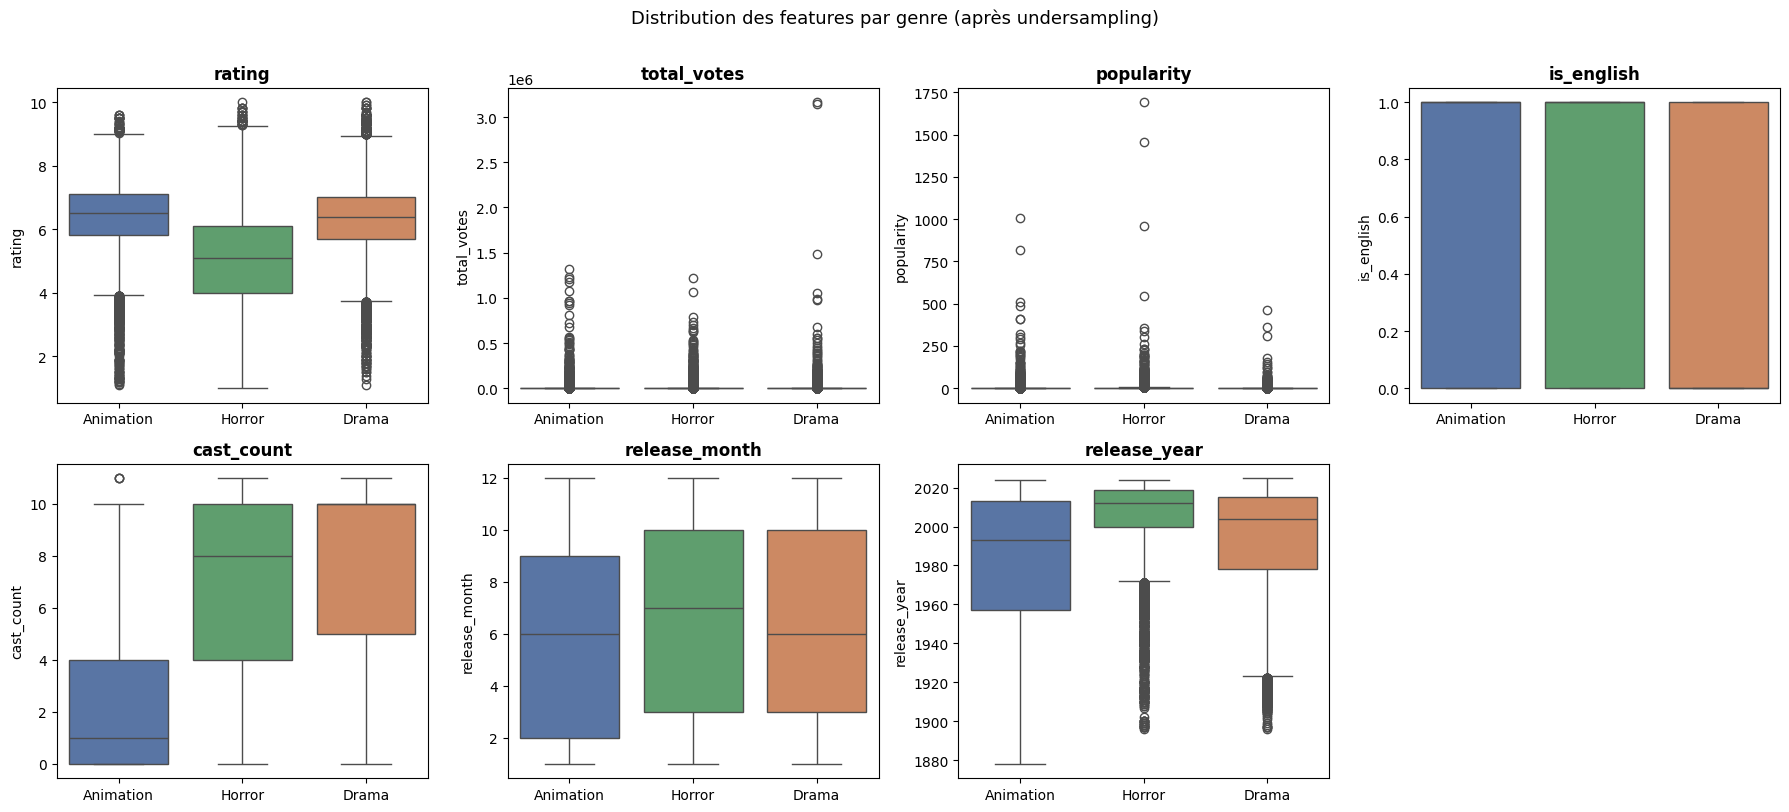

In [3]:
fig, axes = plt.subplots(2, 4, figsize=(18, 8))
axes = axes.flatten()

for i, feat in enumerate(features):
    sns.boxplot(data=df_balanced, x='genre', y=feat, palette=PALETTE,
                order=SELECTED_GENRES, ax=axes[i])
    axes[i].set_title(feat, fontweight='bold')
    axes[i].set_xlabel('')

axes[-1].set_visible(False)
plt.suptitle('Distribution des features par genre (après undersampling)', fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

/var/folders/v0/_lflz19n6hv63x17d4_zjfjm0000gn/T/ipykernel_39935/3057727824.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=df_balanced, x='genre', y=feat, palette=PALETTE,
/var/folders/v0/_lflz19n6hv63x17d4_zjfjm0000gn/T/ipykernel_39935/3057727824.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=df_balanced, x='genre', y=feat, palette=PALETTE,
/var/folders/v0/_lflz19n6hv63x17d4_zjfjm0000gn/T/ipykernel_39935/3057727824.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=df_balanced, x='genre', y=feat, palette=P

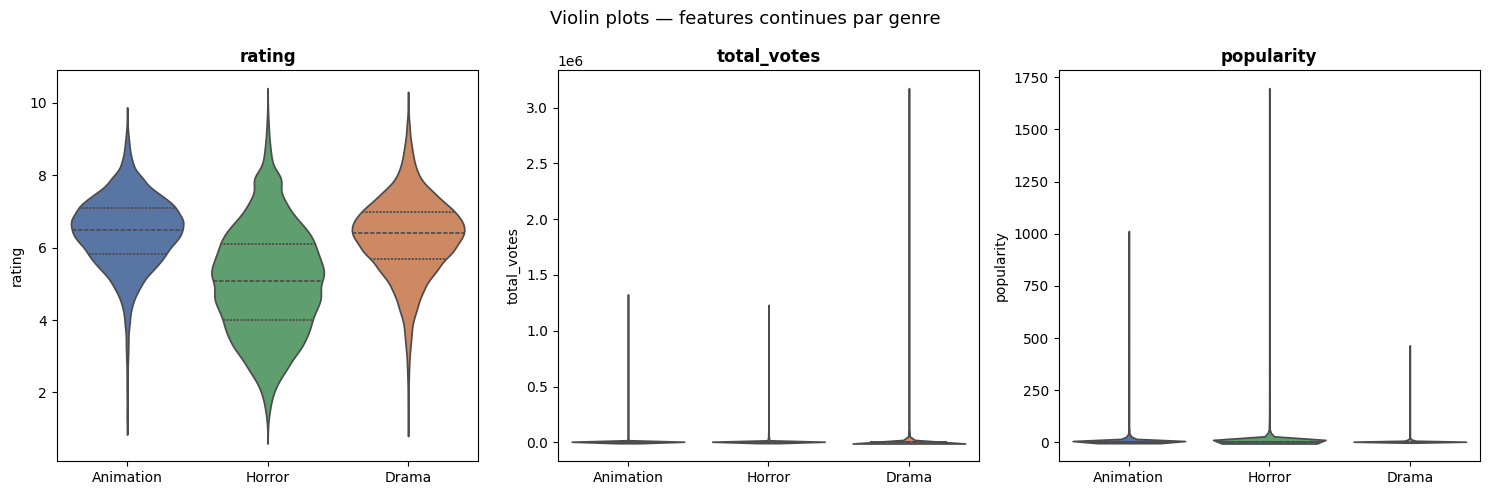

In [4]:
# Violin plots pour les features continues (plus de détail sur la forme)
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for i, feat in enumerate(continuous_features):
    sns.violinplot(data=df_balanced, x='genre', y=feat, palette=PALETTE,
                   order=SELECTED_GENRES, ax=axes[i], inner='quartile')
    axes[i].set_title(feat, fontweight='bold')
    axes[i].set_xlabel('')

plt.suptitle('Violin plots — features continues par genre', fontsize=13)
plt.tight_layout()
plt.show()

---
## 2. Séparabilité des genres

On quantifie à quel point chaque feature sépare les genres avec un **test de Kruskal-Wallis** (non-paramétrique — pas d'hypothèse de normalité requise ici). Une p-value faible indique que les distributions sont significativement différentes entre genres.

In [5]:
print(f"{'Feature':<20} {'H-stat':>10} {'p-value':>12} {'Séparable ?':>14}")
print('-' * 60)

groups = [df_balanced[df_balanced['genre'] == g] for g in SELECTED_GENRES]

for feat in features:
    h, p = stats.kruskal(*[g[feat].dropna() for g in groups])
    flag = '✓ oui' if p < 0.05 else '✗ non'
    print(f"{feat:<20} {h:>10.2f} {p:>12.2e} {flag:>14}")

Feature                  H-stat      p-value    Séparable ?
------------------------------------------------------------
rating                 11197.83     0.00e+00          ✓ oui
total_votes             1976.28     0.00e+00          ✓ oui
popularity              2060.55     0.00e+00          ✓ oui
is_english              5644.06     0.00e+00          ✓ oui
cast_count             17198.87     0.00e+00          ✓ oui
release_month            173.34     2.29e-38          ✓ oui
release_year            5191.59     0.00e+00          ✓ oui


In [6]:
# Tableau des moyennes par genre — ce que le modèle a appris
print("Moyennes par feature et genre :")
print(df_balanced.groupby('genre')[features].mean().round(3).T.to_string())

Moyennes par feature et genre :
genre          Animation     Drama    Horror
rating             6.436     6.304     5.061
total_votes     2694.145  2933.474  4175.374
popularity         2.780     2.238     3.636
is_english         0.630     0.366     0.731
cast_count         2.610     7.602     6.811
release_month      5.961     6.327     6.441
release_year    1984.955  1993.806  2006.080


---
## 3. Vérification de l'hypothèse gaussienne

GaussianNB suppose que chaque feature suit une loi normale $\mathcal{N}(\mu, \sigma^2)$ par classe. On vérifie cette hypothèse visuellement (histogramme + courbe KDE vs gaussienne théorique) et avec un **test de Shapiro-Wilk** (sur un échantillon de 500 pour la performance).

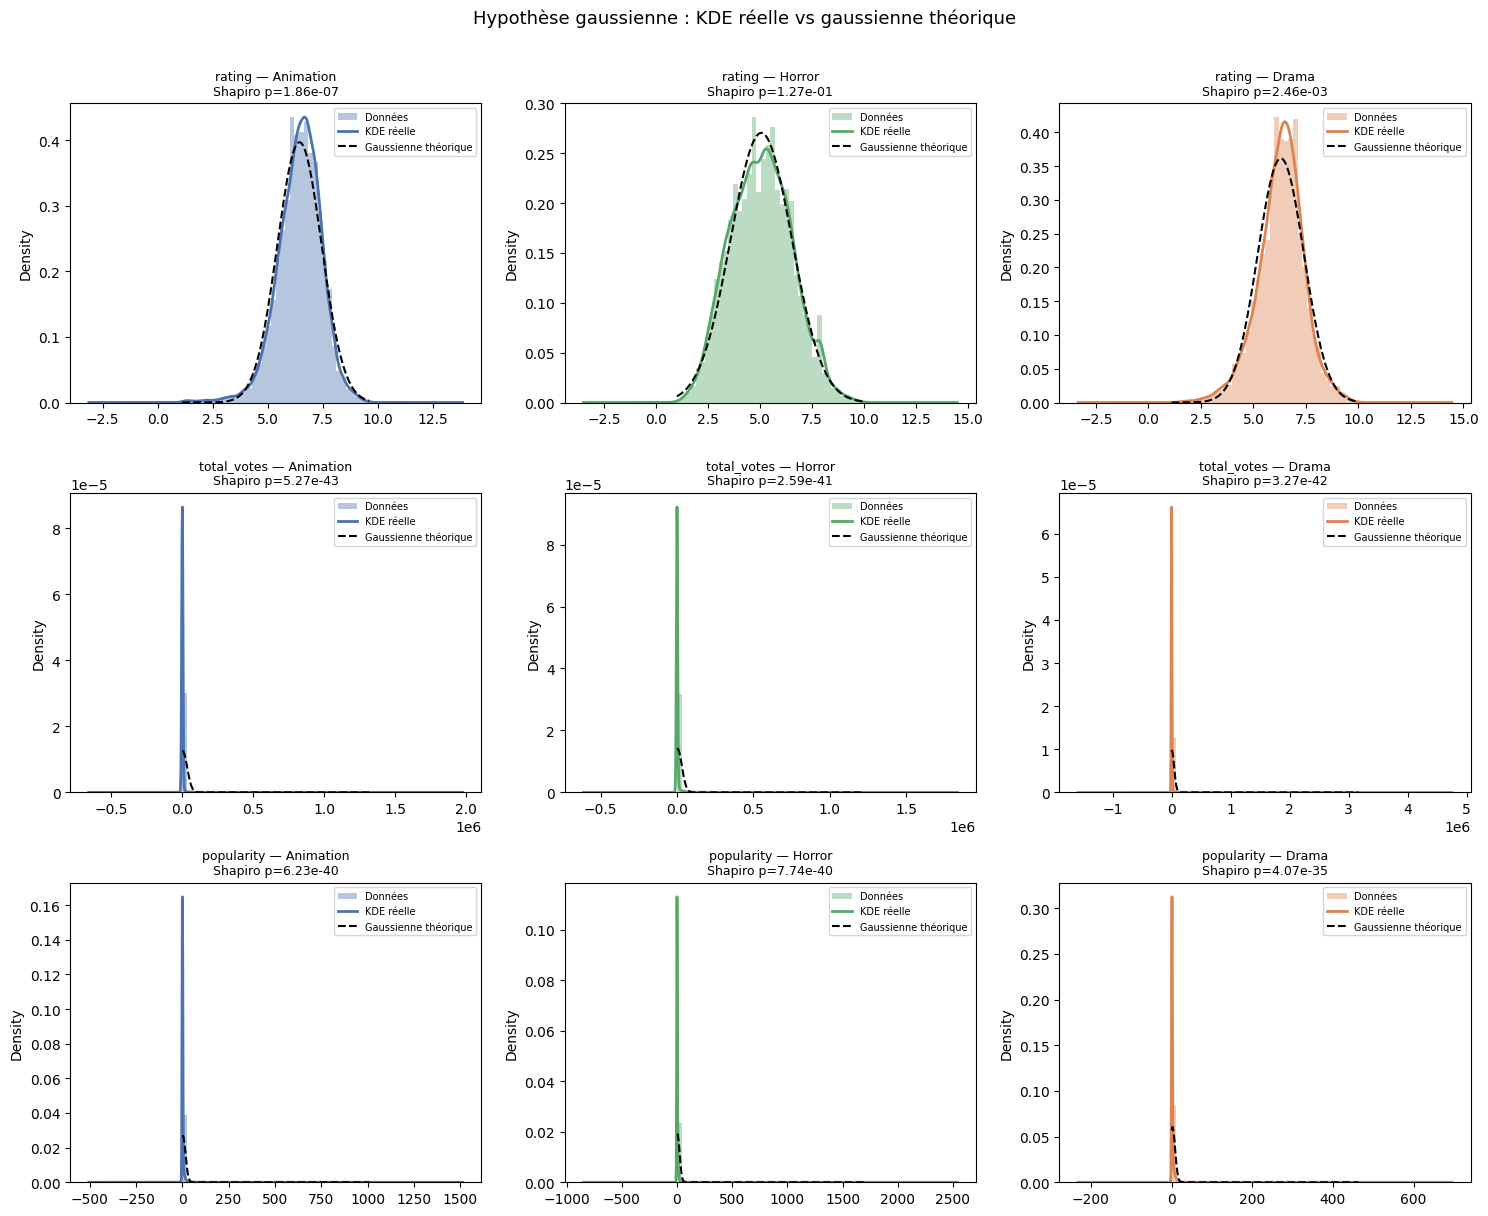

In [7]:
fig, axes = plt.subplots(len(continuous_features), 3, figsize=(15, 4 * len(continuous_features)))

for i, feat in enumerate(continuous_features):
    for j, genre in enumerate(SELECTED_GENRES):
        ax = axes[i][j]
        data = df_balanced[df_balanced['genre'] == genre][feat].dropna()

        # Histogramme + KDE réelle
        ax.hist(data, bins=40, density=True, alpha=0.4, color=PALETTE[genre], label='Données')
        data.plot.kde(ax=ax, color=PALETTE[genre], linewidth=2, label='KDE réelle')

        # Gaussienne théorique
        x = np.linspace(data.min(), data.max(), 200)
        ax.plot(x, stats.norm.pdf(x, data.mean(), data.std()),
                'k--', linewidth=1.5, label='Gaussienne théorique')

        # Shapiro-Wilk sur 500 points
        sample = data.sample(min(500, len(data)), random_state=RANDOM_STATE)
        _, p = stats.shapiro(sample)

        ax.set_title(f'{feat} — {genre}\nShapiro p={p:.2e}', fontsize=9)
        ax.legend(fontsize=7)

plt.suptitle("Hypothèse gaussienne : KDE réelle vs gaussienne théorique", fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

---
## 4. Corrélations entre features

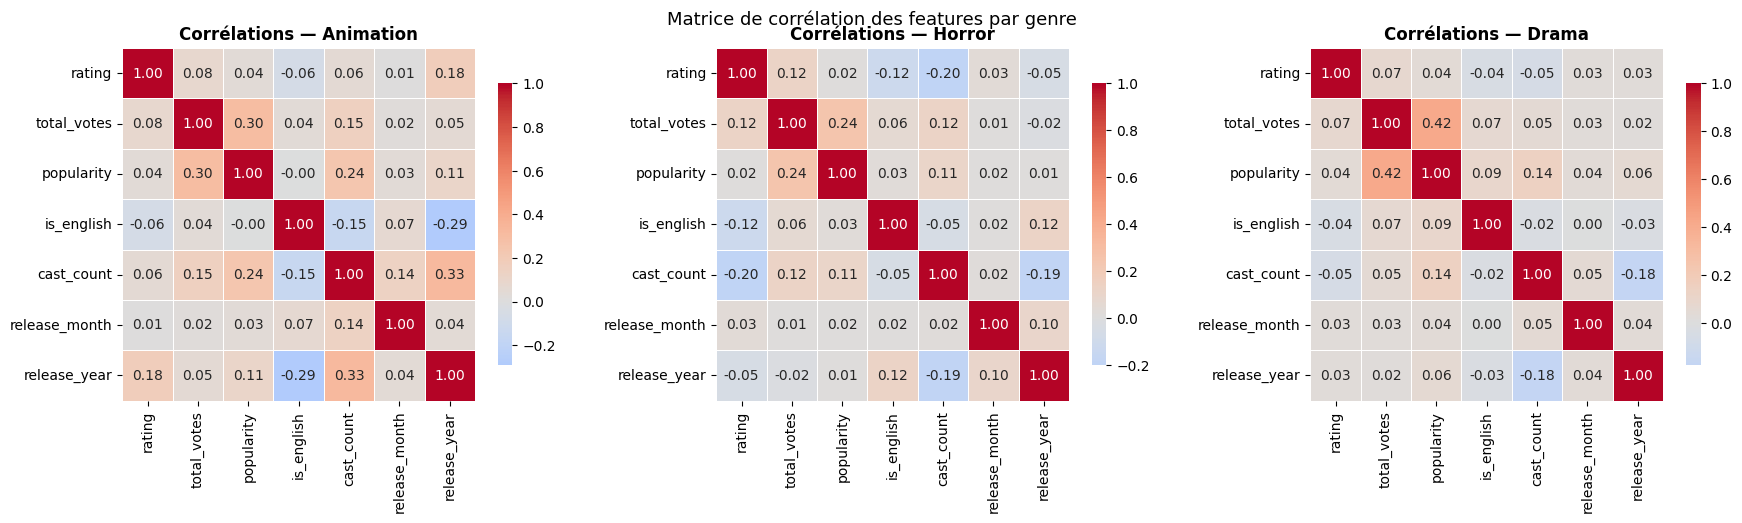

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, genre in zip(axes, SELECTED_GENRES):
    corr = df_balanced[df_balanced['genre'] == genre][features].corr()
    sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0,
                ax=ax, square=True, linewidths=0.5, cbar_kws={'shrink': 0.8})
    ax.set_title(f'Corrélations — {genre}', fontweight='bold')

plt.suptitle('Matrice de corrélation des features par genre', fontsize=13)
plt.tight_layout()
plt.show()

---
## 5. Conclusions

### Features les plus discriminantes (Kruskal-Wallis)

**Toutes les features sont significativement discriminantes** (p ≈ 0 pour toutes). Classement par H-stat (plus élevé = plus discriminant) :

| Feature | H-stat | Observation |
|---|---|---|
| `cast_count` | **17 199** | Animation a très peu d'acteurs (~2.6) vs Drama/Horror (~7) |
| `rating` | 11 198 | Horror a une note bien plus basse (~5.1) vs Animation/Drama (~6.4) |
| `is_english` | 5 645 | Drama peu anglophone (0.37) vs Horror très anglophone (0.73) |
| `release_year` | 5 192 | Animation beaucoup plus ancien (~1985) vs Horror récent (~2006) |
| `popularity` | 2 061 | Horror plus populaire (~3.6) vs Drama moins (~2.2) |
| `total_votes` | 1 976 | Horror plus voté (~4175) vs Animation peu voté (~2694) |
| `release_month` | 173 | Moins discriminant mais significatif |

### Features les moins discriminantes
`release_month` est le moins discriminant (H=173 vs 17k pour `cast_count`) — les genres ne sortent pas vraiment à des mois différents.

### Hypothèse gaussienne
Les p-values Shapiro-Wilk sont toutes très faibles (< 0.05) — **aucune feature ne suit strictement une loi normale**. Cela est attendu avec 19k points (Shapiro est très sensible sur grands échantillons) et visible sur les violin plots : `total_votes` et `popularity` ont des distributions très asymétriques (longue queue à droite).

GaussianNB reste efficace malgré cette violation : le modèle est **robuste aux écarts modérés à la normalité**, surtout quand les distributions sont suffisamment séparées entre classes — ce qui est le cas ici (cf. H-stats élevées).

### Corrélations notables
Les corrélations intra-genre sont globalement faibles, ce qui valide l'**hypothèse d'indépendance conditionnelle** de Naive Bayes. Quelques corrélations modérées attendues : `total_votes` / `popularity` (films populaires = plus votés), `release_year` / `is_english` (films récents plus anglophones).